## Evaluate Modular NN per Drainage Basin

Table 5, Figure 8

run calc_climatology.ipynb beforehand!

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'evaluations')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2, calc_anomaly

fig_dir = os.path.sep.join([base_dir, 'figures'])

MODE = 'test'  # use test set!

In [ ]:
# load daily melt predictions
chunking = {'time': -1, 'y': -1, 'x': -1}
pred_dir = os.path.sep.join([base_dir, 'output', 'melt_modularNN_EBM'])
ds_pred = xr.open_dataset(os.path.sep.join([pred_dir, 'pred_data_1990-2016.zarr'])).chunk(chunking)

# load climatology of predicted melt
snmel_clim_pred = xr.open_zarr(os.path.sep.join([pred_dir, 'pred_climat_1990-2013_15dayrolling.zarr']))['snmel_pred']

# load climatology of true melt
ds_clim = xr.load_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack', 'climat_snmel_1990-2013_smoothed15.nc']))
snmel_clim = ds_clim['snmel'].sel(x=ds_pred['x'], y=ds_pred['y'])


/data1/env_FirnML/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [4]:
# load basins
data_dir = os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'AuxFiles'])
ds_basins = xr.open_dataset(data_dir + '/GRLmask.nc')['maskbas']

basins = {   1: 'N',
            2: 'NE',
            3: 'CE',
             4: 'SE',
             5: 'SW',
             6: 'NW' }

In [5]:
# predict anomalies for 2016 w.r.t. climatology 1990-2013

ds_clim = ds_clim.sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int))

pred_da = ds_pred['snmel_pred'].sel(time=slice('1990-01-01','2016-12-31')).compute()
true_da = ds_pred['snmel_true'].sel(time=slice('1990-01-01','2016-12-31')).compute()

anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'])
anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'])

## Basin-wise Scores of Modular NN

In [ ]:
# Tables 5: Basin-wise scores per year
# this takes a few minutes ...

years = range(1990,2017)

categories = list(basins.values())+['GrIS']
metrics = ['total melt', 'RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies', 'MAE/RMSE']

# Create multi-level index (years × categories)
index = pd.MultiIndex.from_product([years, categories], names=['year', 'basin'])

# Create DataFrame with this index and metric columns
df_per_year = pd.DataFrame(np.nan,  index=index, dtype=float, 
    columns=metrics)

for year in years:
        
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    print(f'Calculate scores per basin for period {start_date} to {end_date} ...')
    pred_da = ds_pred['snmel_pred'].sel(time=slice(start_date, end_date)).compute()
    true_da = ds_pred['snmel_true'].sel(time=slice(start_date, end_date)).compute()

    residual = pred_da - true_da
    annual_sums = true_da.groupby("time.year").sum(dim="time")
    mean_melt = annual_sums.where(ds_basins.notnull()).mean().item()
    df_per_year.loc[(year,'GrIS'), 'total melt'] = mean_melt
    df_per_year.loc[(year,'GrIS'), 'RMSE'] = get_rmse(residual)
    df_per_year.loc[(year,'GrIS'), 'MAE'] = get_mae(residual)
    df_per_year.loc[(year,'GrIS'), 'MBE'] = get_mbe(residual)
    df_per_year.loc[(year,'GrIS'), 'R2'] = get_r2(true_da.values, pred_da.values)
    df_per_year.loc[(year,'GrIS'), 'R2_anomalies'] = get_r2(anomaly_true.sel(time=slice(start_date, end_date)).values, anomaly_pred.sel(time=slice(start_date, end_date)).values)
    df_per_year.loc[(year,'GrIS'), 'MAE/RMSE'] = df_per_year.loc[(year,'GrIS'), 'MAE']/df_per_year.loc[(year,'GrIS'), 'RMSE']

    for i,z in basins.items():
        pred_da_zone = pred_da.where(ds_basins==i, drop=True)
        true_da_zone = true_da.where(ds_basins==i, drop=True)
        mean_melt = annual_sums.where(ds_basins==i).mean().item()
        residual_basin = residual.where(ds_basins==i)
        df_per_year.loc[(year,z), 'total melt'] = mean_melt
        df_per_year.loc[(year,z), 'RMSE'] = get_rmse(residual_basin)
        df_per_year.loc[(year,z), 'MAE'] = get_mae(residual_basin)
        df_per_year.loc[(year,z), 'MBE'] = get_mbe(residual_basin)
        df_per_year.loc[(year,z), 'MAE/RMSE'] = df_per_year.loc[(year,z), 'MAE']/df_per_year.loc[(year,z), 'RMSE']

        anomaly_pred_da_zone = anomaly_pred.sel(time=slice(start_date, end_date)).where(ds_basins==i, drop=True)
        anomaly_true_da_zone = anomaly_true.sel(time=slice(start_date, end_date)).where(ds_basins==i, drop=True)

        df_per_year.loc[(year,z), 'R2'] = get_r2(true_da_zone.values, pred_da_zone.values)
        df_per_year.loc[(year,z), 'R2_anomalies'] = get_r2(anomaly_true_da_zone.values, anomaly_pred_da_zone.values)

display(df_per_year.tail(7).round(2))

total melt  RMSE   MAE   MBE    R2  R2_anomalies  MAE/RMSE
year basin                                                            
2016 N          408.71  0.92  0.17  0.06  0.97          0.81      0.18
     NE         299.84  0.73  0.12 -0.00  0.97          0.84      0.16
     CE         312.06  0.73  0.13 -0.01  0.96          0.83      0.18
     SE         607.67  0.88  0.20 -0.02  0.97          0.92      0.23
     SW         525.01  0.96  0.21 -0.06  0.97          0.89      0.22
     NW         309.64  0.81  0.13  0.05  0.96          0.82      0.17
     GrIS       403.40  0.84  0.16 -0.00  0.97          0.87      0.19

In [ ]:
# Table 5: mean and std across all years
stats = df_per_year.groupby(level='basin').agg(['mean', 'std'])
display(stats.round(2))

total melt          RMSE         MAE         MBE          R2        \
            mean     std  mean   std  mean   std  mean   std  mean   std   
basin                                                                      
CE        272.60   60.23  0.72  0.09  0.12  0.02 -0.00  0.03  0.96  0.01   
GrIS      344.97   78.16  0.81  0.09  0.14  0.02 -0.01  0.03  0.97  0.01   
N         350.39   95.47  1.02  0.15  0.17  0.04 -0.01  0.05  0.95  0.02   
NE        235.27   58.79  0.83  0.15  0.12  0.03 -0.02  0.04  0.95  0.02   
NW        284.44   83.56  0.71  0.12  0.11  0.03 -0.01  0.03  0.96  0.01   
SE        547.97  110.78  0.76  0.08  0.17  0.02  0.01  0.02  0.98  0.01   
SW        441.78  121.88  0.78  0.13  0.15  0.03 -0.01  0.05  0.98  0.01   

      R2_anomalies       MAE/RMSE        
              mean   std     mean   std  
basin                                    
CE            0.85  0.04     0.17  0.01  
GrIS          0.87  0.03     0.17  0.02  
N             0.78  0.07     0.17  0.02  
NE            0.75  0.11     0.14  0.02  
NW            0.88  0.04     0.15  0.02  
SE            0.93  0.02     0.22  0.02  
SW            0.92  0.03     0.20  0.02

## Temporal distribution of over- and underestimations of Modular NN per basin

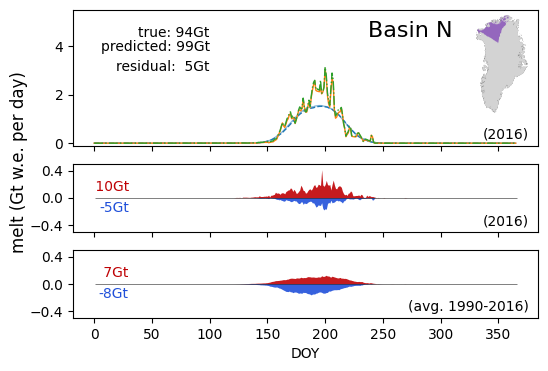

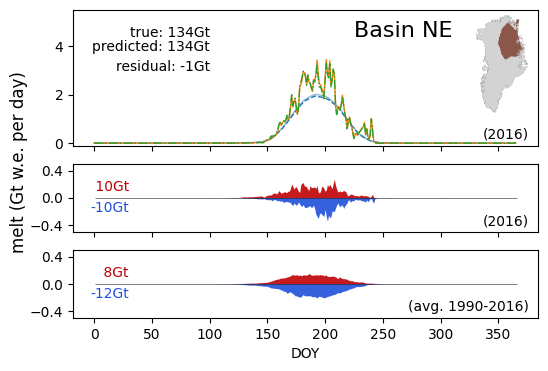

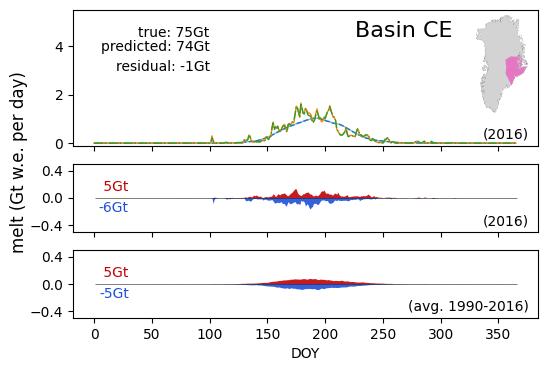

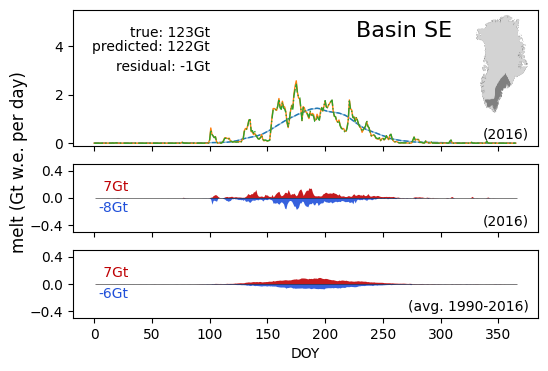

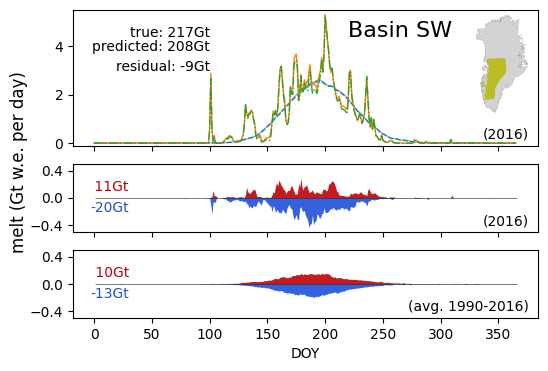

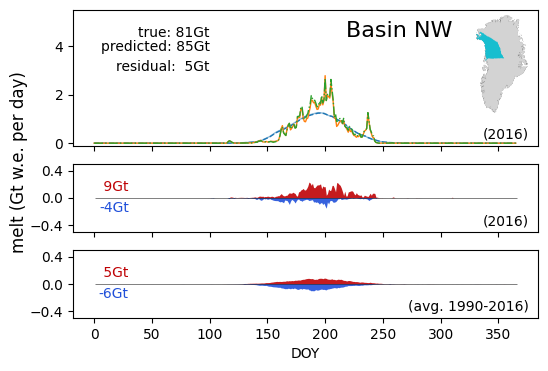

In [ ]:
# Figure 8
# this takes a few minutes ...

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scaling_factor = 1.796553703424 / 58391    # from mm w.e. to Gt
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = [mcolors.to_hex(c) for c in cmap.colors[:3]]
cmap_rb = mcolors.ListedColormap(cc.CET_D1)
blue = cmap_rb.colors[0]
red = cmap_rb.colors[-1]

fig_dir = os.path.sep.join([base_dir, 'figures'])

pred_da = ds_pred['snmel_pred'].sel(time=slice('1990-01-01','2016-12-31'))
true_da = ds_pred['snmel_true'].sel(time=slice('1990-01-01','2016-12-31'))
n_years = len(np.unique(true_da['time.year']))

for i,z in basins.items():
    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(6,4), sharex=True, height_ratios=[2,1,1])

    # plot melt of 2016
    pred_da_zone = pred_da.where(ds_basins==i).sel(time=slice('2016-01-01','2016-12-31'))
    true_da_zone = true_da.where(ds_basins==i).sel(time=slice('2016-01-01','2016-12-31'))
    true_da_zone_total = true_da_zone.sum(dim=['x', 'y']).compute()*scaling_factor
    pred_da_zone_total = pred_da_zone.sum(dim=['x', 'y']).compute()*scaling_factor
    ax0.plot(snmel_clim.where(ds_basins==i).sum(dim=['x', 'y'])*scaling_factor, linewidth=1, label='climatology true', color=colors[0], alpha=0.5)
    ax0.plot(snmel_clim_pred.where(ds_basins==i).sum(dim=['x', 'y'])*scaling_factor, linewidth=1, label='climatology predicted', color=colors[0], linestyle='--')
    ax0.plot(true_da_zone_total, linewidth=1, label=f'true melt', color=colors[1])
    ax0.plot(pred_da_zone_total, linewidth=1, linestyle='-.', label=f'predicted melt', color=colors[2])
    
    ax0.set_ylim(-0.1,5.5)
    ax0.text(376, 0.2, '(2016)', ha='right')
    total_true = true_da_zone_total.sum().item()
    total_pred = pred_da_zone_total.sum().item()
    ax0.text(100, 4.4, f'true: {int(round(total_true)):2d}Gt', ha='right')
    ax0.text(100, 3.8, f'predicted: {int(round(total_pred)):2d}Gt', ha='right')
    ax0.text(100, 3., f'residual: {int(round(total_pred-total_true)):2d}Gt', ha='right')

    basin_img = plt.imread(os.path.sep.join([fig_dir, f'basin_{i}.png']))
    axins = inset_axes(ax0, width="15%", height="80%", loc='upper right', borderpad=0)
    axins.imshow(basin_img)
    axins.axis('off')
    ax0.text(310, 4.4, f'Basin {z}', ha='right', fontsize=16)
        
    # plot residuals of 2016
    residual = pred_da_zone - true_da_zone
    over_t = residual.where(residual>0).sum(dim=['x', 'y']).compute()*scaling_factor
    under_t = residual.where(residual<0).sum(dim=['x', 'y']).compute()*scaling_factor
    ax1.hlines(y=0, xmin=1, xmax=366, color='k', linewidth=0.5, alpha=0.7)
    ax1.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, over_t, label='overestimation', color=red, alpha=0.9, linewidth=0.)
    ax1.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, under_t, label='underestimation', color=blue, alpha=0.9, linewidth=0.)

    ax1.set_ylim(-.5,.5)
    ax1.set_yticks([-0.4, 0, 0.4])
    ax1.text(376, -0.4, '(2016)', ha='right')
    ax1.text(30, 0.1, f' {int(round(over_t.sum().item()))}Gt', color=red, ha='right')
    ax1.text(30, -0.2, f'{int(round(under_t.sum().item()))}Gt', color=blue, ha='right')

    # plot residuals averaged over 1990-2016
    pred_da_zone = pred_da.where(ds_basins==i).sel(time=slice('1990-01-01','2016-12-31'))
    true_da_zone = true_da.where(ds_basins==i).sel(time=slice('1990-01-01','2016-12-31'))
    residual = pred_da_zone - true_da_zone
    over_t = residual.where(residual>0).sum(dim=['x', 'y']).compute()*scaling_factor
    under_t = residual.where(residual<0).sum(dim=['x', 'y']).compute()*scaling_factor
    over_t = over_t.groupby('time.dayofyear').mean(dim='time')
    under_t = under_t.groupby('time.dayofyear').mean(dim='time')
    ax2.hlines(y=0, xmin=1, xmax=366, color='k', linewidth=0.5, alpha=0.7)
    ax2.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, over_t, label='overestimation', color=red, alpha=0.9, linewidth=0.)
    ax2.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, under_t, label='underestimation', color=blue, alpha=0.9, linewidth=0.)

    ax2.set_xlabel('DOY')
    ax2.set_ylim(-.5,.5)
    ax2.set_yticks([-0.4, 0, 0.4])
    ax2.text(376, -0.4, '(avg. 1990-2016)', ha='right')
    ax2.text(30, 0.1, f' {int(round(over_t.sum().item()))}Gt', color=red, ha='right')
    ax2.text(30, -0.2, f'{int(round(under_t.sum().item()))}Gt', color=blue, ha='right')
    
    fig.supylabel('melt (Gt w.e. per day)')

    fig.savefig(os.path.sep.join([fig_dir, f'modularNN_EBM_basin{z}.png']), bbox_inches='tight', dpi=300)
    plt.show()


# --- build and save legend as its own figure ---
handles, labels = ax0.get_legend_handles_labels()
fig_legend = plt.figure(figsize=(5, 1))
leg = fig_legend.legend(handles, labels, loc='center', frameon=False, ncol=4)
fig_legend.canvas.draw()

fig_legend.savefig(os.path.sep.join([fig_dir, "modularNN_EBM_basins_legend.png"]), bbox_inches='tight', dpi=200)
plt.close(fig_legend)